# GW-MDS indutivo — destilação versus treinamento neural direto

Este notebook compara duas extensões indutivas single-view sob a mesma divisão
treino/teste:

1. **GW-MDS + destilação:** o GW-MDS é ajustado somente no treino, sua projeção
   baricêntrica fornece os alvos e uma MLP aprende esses alvos por MSE;
2. **MLP-GW direta:** a MLP produz o embedding e seus parâmetros são atualizados
   diretamente pela perda de Gromov–Wasserstein.

A geometria relacional pode ser definida pelas distâncias **euclidiana**,
**geodésica (Isomap)** ou **cosseno**. Em todas as alternativas, as amostras de
teste permanecem fora do cálculo GW, do ajuste dos escalonadores e do treinamento
neural.

Na avaliação geodésica, o grafo de vizinhança é construído com o conjunto
completo de amostras e, em seguida, é extraído o bloco teste × teste da matriz de
caminhos mínimos. Esse uso do treino ocorre somente na construção da referência
geométrica de avaliação; ele não altera o teacher nem os students.

In [1]:
%pip -q install POT


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 39.5 MB/s eta 0:00:00


In [2]:
import copy
import math
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import ot
import pandas as pd
import torch
import torch.nn as nn

from scipy.sparse.csgraph import connected_components
from scipy.stats import pearsonr, spearmanr
from sklearn.datasets import make_s_curve
from sklearn.decomposition import PCA
from sklearn.manifold import Isomap, trustworthiness
from sklearn.metrics import pairwise_distances
from sklearn.model_selection import train_test_split
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import MinMaxScaler, StandardScaler


SEED = 0

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("POT:", ot.__version__)
print("PyTorch:", torch.__version__)
print("CUDA disponível para a MLP:", torch.cuda.is_available())


POT: 0.9.7
PyTorch: 2.11.0+cpu
CUDA disponível para a MLP: False


## 1. Dados e separação treino/teste

São geradas 1.250 amostras: 1.000 para treino e 250 para teste. O
`MinMaxScaler` é ajustado exclusivamente com o treino e sua transformação é
reutilizada no teste. O parâmetro `t` retornado por `make_s_curve` é usado apenas
para colorir as figuras.

In [3]:
# Configuração do experimento
N_SAMPLES = 1250
TEST_SIZE = 0.20
NOISE = 0.05

# Geometria relacional
# Opções: "euclidean", "geodesic" ou "cosine"
DISTANCE_TYPE = "geodesic"
N_NEIGHBORS = 12
NORMALIZE_DISTANCES = True
TRUSTWORTHINESS_NEIGHBORS = 10

# Configuração do professor GW-MDS
GW_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
GW_COMPONENTS = 2
GW_ITERATIONS = 100
GW_LR = 0.10
GW_INIT = "random"       # opções: "random" ou "pca"
GW_INNER_MAX_ITER = 100

# Configuração do aluno MLP
MLP_MAX_EPOCHS = 3000
MLP_PATIENCE = 250
MLP_LR = 1e-3

# Configuração da MLP treinada diretamente pela perda GW
# O mesmo número de atualizações GW do professor torna o custo comparável.
DIRECT_GW_ITERATIONS = GW_ITERATIONS
DIRECT_GW_LR = 1e-3
DIRECT_GW_INNER_MAX_ITER = GW_INNER_MAX_ITER


X_all_raw, t_all = make_s_curve(
    n_samples=N_SAMPLES,
    noise=NOISE,
    random_state=SEED,
)

indices = np.arange(N_SAMPLES)
idx_train, idx_test = train_test_split(
    indices,
    test_size=TEST_SIZE,
    random_state=SEED,
    shuffle=True,
)

x_scaler = MinMaxScaler()
X_train = x_scaler.fit_transform(X_all_raw[idx_train]).astype(np.float32)
X_test = x_scaler.transform(X_all_raw[idx_test]).astype(np.float32)
t_train = t_all[idx_train]
t_test = t_all[idx_test]

print("Treino:", X_train.shape)
print("Teste :", X_test.shape)
print("Distância selecionada:", DISTANCE_TYPE)


Treino: (1000, 3)
Teste : (250, 3)
Distância selecionada: geodesic


## 2. Construção da geometria relacional

`D_train` é sempre calculada apenas com o treino. Para a distância geodésica,
o Isomap calcula os caminhos mínimos no grafo $k$-NN.

Na avaliação geodésica de teste, o grafo contém treino e teste. Somente depois
do cálculo da matriz geodésica completa é extraído o bloco teste × teste e
normalizado. Isso permite que um caminho entre duas amostras de teste atravesse
amostras do conjunto original, sem usar o teste no treinamento.

In [4]:
def normalize_distance_matrix(D, normalize=True, eps=1e-12):
    D = np.asarray(D, dtype=np.float64)
    if D.ndim != 2 or D.shape[0] != D.shape[1]:
        raise ValueError("A matriz de distâncias deve ser quadrada.")

    D = 0.5 * (D + D.T)
    np.fill_diagonal(D, 0.0)

    if not np.isfinite(D).all():
        raise ValueError("A matriz de distâncias contém valores não finitos.")

    if normalize:
        scale = max(float(D.max()), eps)
        D = D / scale

    return D.astype(np.float32)


def geodesic_distance_matrix(X, n_neighbors=12):
    X = np.asarray(X, dtype=np.float64)
    n_samples = X.shape[0]
    if n_samples < 3:
        raise ValueError("São necessárias pelo menos três amostras.")

    requested_k = min(max(2, int(n_neighbors)), n_samples - 1)
    k = requested_k

    # Verifica a conectividade antes de chamar o Isomap. Se necessário,
    # aumenta k para que existam caminhos mínimos finitos entre todos os pares.
    while True:
        graph = kneighbors_graph(
            X,
            n_neighbors=k,
            mode="distance",
            include_self=False,
        )
        graph = graph.maximum(graph.T)
        n_components, _ = connected_components(graph, directed=False)

        if n_components == 1:
            break
        if k == n_samples - 1:
            raise RuntimeError(
                "Não foi possível construir um grafo de vizinhança conectado."
            )
        k = min(
            n_samples - 1,
            max(k + 1, int(math.ceil(1.5 * k))),
        )

    if k != requested_k:
        print(
            f"Grafo k-NN desconectado: k aumentado de "
            f"{requested_k} para {k}."
        )

    isomap = Isomap(
        n_neighbors=k,
        n_components=2,
    )
    isomap.fit(X)
    D = np.asarray(isomap.dist_matrix_, dtype=np.float64)

    if not np.isfinite(D).all():
        raise RuntimeError(
            "O Isomap produziu caminhos mínimos não finitos."
        )
    return D


def compute_distance_matrix(
    X,
    distance_type="euclidean",
    n_neighbors=12,
    normalize=True,
):
    distance_type = distance_type.lower()

    if distance_type == "euclidean":
        D = pairwise_distances(X, metric="euclidean")
    elif distance_type == "geodesic":
        D = geodesic_distance_matrix(
            X,
            n_neighbors=n_neighbors,
        )
    elif distance_type == "cosine":
        D = pairwise_distances(X, metric="cosine")
    else:
        raise ValueError(
            "DISTANCE_TYPE deve ser 'euclidean', 'geodesic' ou 'cosine'."
        )

    return normalize_distance_matrix(D, normalize=normalize)


# A geometria de treino nunca utiliza as amostras de teste.
D_train = compute_distance_matrix(
    X_train,
    distance_type=DISTANCE_TYPE,
    n_neighbors=N_NEIGHBORS,
    normalize=NORMALIZE_DISTANCES,
)


if DISTANCE_TYPE.lower() == "geodesic":
    # Referência de avaliação: grafo completo treino + teste.
    X_full_for_geodesic_evaluation = np.concatenate(
        [X_train, X_test],
        axis=0,
    )
    D_full = compute_distance_matrix(
        X_full_for_geodesic_evaluation,
        distance_type="geodesic",
        n_neighbors=N_NEIGHBORS,
        normalize=False,
    )

    n_train = len(X_train)
    D_test = D_full[n_train:, n_train:].copy()
    D_test = normalize_distance_matrix(
        D_test,
        normalize=NORMALIZE_DISTANCES,
    )
    print(
        "Avaliação geodésica: bloco teste × teste extraído "
        "do grafo completo."
    )
else:
    # Em distâncias diretas, o treino não altera as distâncias teste × teste.
    D_test = compute_distance_matrix(
        X_test,
        distance_type=DISTANCE_TYPE,
        n_neighbors=N_NEIGHBORS,
        normalize=NORMALIZE_DISTANCES,
    )


print("D_train:", D_train.shape)
print("D_test :", D_test.shape)


Avaliação geodésica: bloco teste × teste extraído do grafo completo.
D_train: (1000, 1000)
D_test : (250, 250)


## 3. Professor: GW-MDS transdutivo

O teacher recebe diretamente `D_train`, construída com a distância selecionada.
Durante cada iteração, o plano $T$ é calculado com $Y$ fixo. Em seguida, o
objetivo GW quadrático é diferenciado em relação a $Y$, mantendo $T$ fixo. Ao
terminar, o plano é **recalculado** com o último valor de $Y$.

Para matrizes simétricas e perda quadrática, usamos a forma equivalente

$$
\mathcal{L}_{\mathrm{GW}}
=
\langle D_X^2,aa^\top\rangle
+\langle D_Y^2,bb^\top\rangle
-2\langle D_XTD_Y^\top,T\rangle.
$$

In [5]:
def initialize_embedding(X_np, n_components=2, init="random", seed=42):
    # Mantém a escala original da inicialização, como no GW-MDS original.
    if init == "pca":
        y0 = PCA(n_components=n_components, random_state=seed).fit_transform(X_np)
        y0 = torch.tensor(y0, dtype=torch.float32)
    elif init == "random":
        generator = torch.Generator().manual_seed(seed)
        y0 = torch.randn(
            X_np.shape[0],
            n_components,
            generator=generator,
            dtype=torch.float32,
        )
    else:
        raise ValueError("init deve ser 'random' ou 'pca'.")

    return y0


def squared_gw_loss_fixed_plan(DX, DY, T, a, b):
    # Objetivo GW quadrático diferenciável em DY, com T mantido fixo.
    const_x = torch.sum(DX.square() * torch.outer(a, a))
    const_y = torch.sum(DY.square() * torch.outer(b, b))
    cross = torch.sum((DX @ T @ DY.T) * T)
    return const_x + const_y - 2.0 * cross


def solve_gw_plan(
    DX,
    DY,
    a,
    b,
    initial_plan=None,
    inner_max_iter=100,
):
    # initial_plan=None deixa o solver GW escolher sua inicialização padrão.
    kwargs = {}
    if initial_plan is not None:
        kwargs["G0"] = initial_plan

    return ot.gromov.gromov_wasserstein(
        DX,
        DY,
        a,
        b,
        loss_fun="square_loss",
        symmetric=True,
        armijo=False,
        log=False,
        verbose=False,
        max_iter=inner_max_iter,
        tol_rel=1e-5,
        tol_abs=1e-5,
        **kwargs,
    )


def fit_gwmds(
    X_np,
    D_source,
    n_components=2,
    n_iterations=100,
    lr=0.1,
    init="random",
    seed=42,
    inner_max_iter=100,
    print_every=10,
    device=None,
):
    # Ajusta o GW-MDS e devolve Y livre, T final e projeção baricêntrica.
    device = torch.device(
        device or ("cuda" if torch.cuda.is_available() else "cpu")
    )
    n = X_np.shape[0]
    D_source = np.asarray(D_source, dtype=np.float32)
    if D_source.shape != (n, n):
        raise ValueError("D_source deve ter formato (n_amostras, n_amostras).")

    DX = torch.as_tensor(D_source, dtype=torch.float32, device=device)
    a = torch.full((n,), 1.0 / n, dtype=torch.float32, device=device)
    b = torch.full((n,), 1.0 / n, dtype=torch.float32, device=device)

    Y = initialize_embedding(X_np, n_components, init, seed).to(device)
    Y.requires_grad_(True)
    optimizer = torch.optim.Adam([Y], lr=lr)
    history = []

    start = time.time()
    for iteration in range(1, n_iterations + 1):
        optimizer.zero_grad()
        DY = torch.cdist(Y, Y, p=2)

        with torch.no_grad():
            T = solve_gw_plan(
                DX,
                DY,
                a,
                b,
                initial_plan=None,
                inner_max_iter=inner_max_iter,
            )

        loss = squared_gw_loss_fixed_plan(DX, DY, T, a, b)
        loss.backward()
        optimizer.step()

        # A translação de Y não altera distâncias; centralizar evita deriva numérica.
        with torch.no_grad():
            Y -= Y.mean(dim=0, keepdim=True)

        history.append(float(loss.detach()))
        if iteration == 1 or iteration % print_every == 0:
            print(f"GW-MDS {iteration:03d}/{n_iterations} | loss = {history[-1]:.8f}")

    # T_final deve corresponder ao Y posterior à última atualização.
    with torch.no_grad():
        DY_final = torch.cdist(Y, Y, p=2)
        T_final = solve_gw_plan(
            DX,
            DY_final,
            a,
            b,
            initial_plan=None,
            inner_max_iter=inner_max_iter,
        )

        row_mass = T_final.sum(dim=1, keepdim=True).clamp_min(1e-12)
        Y_teacher = (T_final @ Y) / row_mass

    return {
        "Y_free": Y.detach().cpu().numpy(),
        "T_final": T_final.detach().cpu().numpy(),
        "Y_teacher": Y_teacher.detach().cpu().numpy(),
        "DX": DX.detach().cpu().numpy(),
        "history": np.asarray(history),
        "execution_time": time.time() - start,
    }


In [6]:
teacher = fit_gwmds(
    X_train,
    D_train,
    n_components=GW_COMPONENTS,
    n_iterations=GW_ITERATIONS,
    lr=GW_LR,
    init=GW_INIT,
    seed=SEED,
    inner_max_iter=GW_INNER_MAX_ITER,
    device=GW_DEVICE,
)

Y_teacher_train = teacher["Y_teacher"]

print(f"\nTempo do GW-MDS: {teacher['execution_time']:.2f} s")
print("Embedding professor:", Y_teacher_train.shape)
print(
    "Soma mínima/máxima das linhas de T:",
    teacher["T_final"].sum(axis=1).min(),
    teacher["T_final"].sum(axis=1).max(),
)


GW-MDS 001/100 | loss = 2.74154806
GW-MDS 010/100 | loss = 0.40806520
GW-MDS 020/100 | loss = 0.05328441
GW-MDS 030/100 | loss = 0.01136211
GW-MDS 040/100 | loss = 0.00273064
GW-MDS 050/100 | loss = 0.00157145
GW-MDS 060/100 | loss = 0.00046769
GW-MDS 070/100 | loss = 0.00033981
GW-MDS 080/100 | loss = 0.00052607
GW-MDS 090/100 | loss = 0.00018749
GW-MDS 100/100 | loss = 0.00012192

Tempo do GW-MDS: 246.54 s
Embedding professor: (1000, 2)
Soma mínima/máxima das linhas de T: 0.001 0.001


## 4. Aluno: MLP para projeção out-of-sample

A MLP aprende diretamente

$$
f_\theta(x_i)\approx \bar y_i^\star,
\qquad
\bar y_i^\star=
\frac{\sum_jT_{ij}^\star y_j^\star}{\sum_jT_{ij}^\star}.
$$

Uma parte do treino é reservada para validação e parada antecipada. As amostras de teste permanecem completamente fora desse processo.


In [7]:
class InductiveMLP(nn.Module):
    def __init__(self, input_dim=3, output_dim=2):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim),
        )

    def forward(self, x):
        return self.network(x)


def fit_inductive_mlp(
    X_np,
    Y_target_np,
    max_epochs=3000,
    patience=250,
    lr=1e-3,
    seed=42,
):
    start = time.time()
    indices = np.arange(len(X_np))
    idx_fit, idx_val = train_test_split(
        indices,
        test_size=0.15,
        random_state=seed,
        shuffle=True,
    )

    # Padronizar somente os alvos facilita a regressão; a transformação é invertida.
    y_scaler = StandardScaler()
    y_scaler.fit(Y_target_np[idx_fit])
    Y_scaled = y_scaler.transform(Y_target_np).astype(np.float32)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = InductiveMLP(X_np.shape[1], Y_target_np.shape[1]).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    criterion = nn.MSELoss()

    X_fit_t = torch.tensor(X_np[idx_fit], dtype=torch.float32, device=device)
    Y_fit_t = torch.tensor(Y_scaled[idx_fit], dtype=torch.float32, device=device)
    X_val_t = torch.tensor(X_np[idx_val], dtype=torch.float32, device=device)
    Y_val_t = torch.tensor(Y_scaled[idx_val], dtype=torch.float32, device=device)

    best_state = None
    best_val = np.inf
    wait = 0
    train_history = []
    val_history = []

    for epoch in range(1, max_epochs + 1):
        model.train()
        optimizer.zero_grad()
        train_loss = criterion(model(X_fit_t), Y_fit_t)
        train_loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_t), Y_val_t)

        train_value = float(train_loss.detach())
        val_value = float(val_loss.detach())
        train_history.append(train_value)
        val_history.append(val_value)

        if val_value < best_val - 1e-8:
            best_val = val_value
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1

        if epoch == 1 or epoch % 250 == 0:
            print(
                f"MLP {epoch:04d}/{max_epochs} | "
                f"train = {train_value:.6f} | val = {val_value:.6f}"
            )

        if wait >= patience:
            print(f"Parada antecipada na época {epoch}; melhor val = {best_val:.6f}")
            break

    model.load_state_dict(best_state)
    return model, y_scaler, {
        "train": np.asarray(train_history),
        "val": np.asarray(val_history),
        "best_val": best_val,
        "device": device,
        "execution_time": time.time() - start,
    }


def predict_embedding(model, y_scaler, X_np, device):
    model.eval()
    with torch.no_grad():
        X_t = torch.tensor(X_np, dtype=torch.float32, device=device)
        prediction_scaled = model(X_t).cpu().numpy()
    return y_scaler.inverse_transform(prediction_scaled)


In [8]:
student, y_scaler, mlp_history = fit_inductive_mlp(
    X_train,
    Y_teacher_train,
    max_epochs=MLP_MAX_EPOCHS,
    patience=MLP_PATIENCE,
    lr=MLP_LR,
    seed=SEED,
)

Y_pred_train = predict_embedding(
    student, y_scaler, X_train, mlp_history["device"]
)
Y_pred_test = predict_embedding(
    student, y_scaler, X_test, mlp_history["device"]
)

teacher_mse_train = np.mean((Y_pred_train - Y_teacher_train) ** 2)
print(f"MSE aluno → projeção baricêntrica no treino: {teacher_mse_train:.8f}")

print(f"Tempo da MLP por destilação: {mlp_history['execution_time']:.2f} s")


MLP 0001/3000 | train = 1.020338 | val = 1.002610
MLP 0250/3000 | train = 0.028265 | val = 0.030093
MLP 0500/3000 | train = 0.005133 | val = 0.005900
MLP 0750/3000 | train = 0.003861 | val = 0.004662
MLP 1000/3000 | train = 0.003434 | val = 0.004273
MLP 1250/3000 | train = 0.003280 | val = 0.004107
MLP 1500/3000 | train = 0.003160 | val = 0.004037
MLP 1750/3000 | train = 0.003083 | val = 0.004001
MLP 2000/3000 | train = 0.003033 | val = 0.004017
MLP 2250/3000 | train = 0.002997 | val = 0.003940
MLP 2500/3000 | train = 0.002951 | val = 0.003976
MLP 2750/3000 | train = 0.002918 | val = 0.003926
MLP 3000/3000 | train = 0.002891 | val = 0.003904
MSE aluno → projeção baricêntrica no treino: 0.00013136
Tempo da MLP por destilação: 5.90 s


## 5. Alternativa: MLP treinada diretamente pela perda GW

Agora o embedding das amostras de treino é produzido pela própria rede,

$$
Y_\theta=f_\theta(X_{\mathrm{train}}),
$$

e os parâmetros são atualizados por

$$
\min_\theta
\operatorname{GW}_2^2\!\left(D_X,D_{Y_\theta}\right).
$$

Em cada iteração, o plano ótimo é recalculado com a saída atual da rede e
mantido fixo durante a retropropagação. Portanto, não diferenciamos através do
solver de transporte. A centralização e a normalização do diâmetro removem as
indeterminações de translação e escala; na inferência de teste são reutilizados
os fatores calculados no treino.

In [9]:
def normalize_train_embedding(Y_raw):
    # Esta normalização pertence à MLP-GW direta e deve ser mantida.
    output_mean = Y_raw.mean(dim=0, keepdim=True)
    Y_centered = Y_raw - output_mean
    output_scale = torch.cdist(Y_centered, Y_centered).max().clamp_min(1e-12)
    return Y_centered / output_scale, output_mean, output_scale


def fit_direct_gw_mlp(
    X_np,
    D_source,
    n_components=2,
    n_iterations=100,
    lr=1e-3,
    seed=42,
    inner_max_iter=100,
    print_every=10,
    device=None,
):
    # Ajusta f_theta diretamente pelo objetivo GW no conjunto de treino.
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    device = torch.device(
        device or ("cuda" if torch.cuda.is_available() else "cpu")
    )
    X_t = torch.tensor(X_np, dtype=torch.float32, device=device)
    n = X_t.shape[0]
    D_source = np.asarray(D_source, dtype=np.float32)
    if D_source.shape != (n, n):
        raise ValueError("D_source deve ter formato (n_amostras, n_amostras).")

    DX = torch.as_tensor(D_source, dtype=torch.float32, device=device)
    a = torch.full((n,), 1.0 / n, dtype=torch.float32, device=device)
    b = torch.full((n,), 1.0 / n, dtype=torch.float32, device=device)

    model = InductiveMLP(X_np.shape[1], n_components).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    history = []
    start = time.time()

    for iteration in range(1, n_iterations + 1):
        model.train()
        optimizer.zero_grad()

        Y_raw = model(X_t)
        Y_train, _, _ = normalize_train_embedding(Y_raw)
        DY = torch.cdist(Y_train, Y_train, p=2)

        with torch.no_grad():
            T = solve_gw_plan(
                DX.detach(),
                DY.detach(),
                a,
                b,
                initial_plan=None,
                inner_max_iter=inner_max_iter,
            )

        loss = squared_gw_loss_fixed_plan(DX, DY, T, a, b)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
        optimizer.step()

        history.append(float(loss.detach()))
        if iteration == 1 or iteration % print_every == 0:
            print(
                f"MLP-GW direta {iteration:03d}/{n_iterations} | "
                f"loss = {history[-1]:.8f}"
            )

    # Estes fatores do treino serão reutilizados para todas as novas amostras.
    model.eval()
    with torch.no_grad():
        Y_raw_final = model(X_t)
        Y_train_final, output_mean, output_scale = normalize_train_embedding(
            Y_raw_final
        )
        DY_final = torch.cdist(Y_train_final, Y_train_final, p=2)
        T_final = solve_gw_plan(
            DX,
            DY_final,
            a,
            b,
            initial_plan=None,
            inner_max_iter=inner_max_iter,
        )
        final_loss = squared_gw_loss_fixed_plan(
            DX,
            DY_final,
            T_final,
            a,
            b,
        )

    return model, {
        "Y_train": Y_train_final.cpu().numpy(),
        "output_mean": output_mean.cpu().numpy(),
        "output_scale": float(output_scale),
        "T_final": T_final.cpu().numpy(),
        "history": np.asarray(history),
        "final_loss": float(final_loss),
        "DX": DX.cpu().numpy(),
        "execution_time": time.time() - start,
        "device": device,
    }


def predict_direct_gw_embedding(model, X_np, direct_info):
    # Usa somente os fatores obtidos no treino, inclusive para dados de teste.
    device = direct_info["device"]
    model.eval()
    with torch.no_grad():
        X_t = torch.tensor(X_np, dtype=torch.float32, device=device)
        Y_raw = model(X_t)
        output_mean = torch.tensor(
            direct_info["output_mean"],
            dtype=torch.float32,
            device=device,
        )
        output_scale = torch.tensor(
            direct_info["output_scale"],
            dtype=torch.float32,
            device=device,
        )
        Y = (Y_raw - output_mean) / output_scale.clamp_min(1e-12)
    return Y.cpu().numpy()


In [10]:
direct_model, direct_info = fit_direct_gw_mlp(
    X_train,
    D_train,
    n_components=GW_COMPONENTS,
    n_iterations=DIRECT_GW_ITERATIONS,
    lr=DIRECT_GW_LR,
    seed=SEED,
    inner_max_iter=DIRECT_GW_INNER_MAX_ITER,
    device=GW_DEVICE,
)

Y_direct_train = direct_info["Y_train"]
Y_direct_test = predict_direct_gw_embedding(
    direct_model,
    X_test,
    direct_info,
)

print(f"\nTempo da MLP-GW direta: {direct_info['execution_time']:.2f} s")
print(f"Perda GW final: {direct_info['final_loss']:.8f}")
print("Embedding direto — treino:", Y_direct_train.shape)
print("Embedding direto — teste :", Y_direct_test.shape)


MLP-GW direta 001/100 | loss = 0.00620714
MLP-GW direta 010/100 | loss = 0.00118217
MLP-GW direta 020/100 | loss = 0.00067070
MLP-GW direta 030/100 | loss = 0.00089902
MLP-GW direta 040/100 | loss = 0.00090325
MLP-GW direta 050/100 | loss = 0.00034884
MLP-GW direta 060/100 | loss = 0.00087884
MLP-GW direta 070/100 | loss = 0.00049287
MLP-GW direta 080/100 | loss = 0.00034633
MLP-GW direta 090/100 | loss = 0.00035584
MLP-GW direta 100/100 | loss = 0.00086132

Tempo da MLP-GW direta: 219.00 s
Perda GW final: 0.00041726
Embedding direto — treino: (1000, 2)
Embedding direto — teste : (250, 2)


## 6. Avaliação relacional e comparação

Pearson, Spearman e stress são calculados a partir da matriz relacional
selecionada (`D_train` ou `D_test`) e das distâncias euclidianas do embedding.
A trustworthiness também usa a matriz relacional como entrada
`metric="precomputed"`.

Na distância geodésica, `D_test` é o bloco teste × teste da matriz de caminhos
mínimos calculada sobre o grafo completo. Nas distâncias euclidiana e cosseno,
`D_test` é calculada diretamente sobre o teste.

In [11]:
def upper_triangle_values(D):
    D = np.asarray(D)
    return D[np.triu_indices_from(D, k=1)]


def relational_metrics_from_distance(
    D_source,
    Y_np,
    n_neighbors=10,
):
    D_source = np.asarray(D_source, dtype=np.float64)
    D_embedding = pairwise_distances(Y_np, metric="euclidean")

    source_values = upper_triangle_values(D_source)
    embedding_values = upper_triangle_values(D_embedding)
    valid = np.isfinite(source_values) & np.isfinite(embedding_values)
    source_values = source_values[valid]
    embedding_values = embedding_values[valid]

    if source_values.size < 2:
        raise ValueError("Não há pares válidos suficientes para a avaliação.")

    pearson = float(pearsonr(source_values, embedding_values)[0])
    spearman = float(spearmanr(source_values, embedding_values)[0])

    # Multiplica D_embedding por alpha para ignorar uma escala global.
    denominator = max(
        float(np.dot(embedding_values, embedding_values)),
        1e-12,
    )
    alpha = float(
        np.dot(source_values, embedding_values) / denominator
    )
    stress = float(
        np.sqrt(
            np.sum(
                (source_values - alpha * embedding_values) ** 2
            )
            / max(np.sum(source_values ** 2), 1e-12)
        )
    )

    safe_neighbors = min(
        int(n_neighbors),
        max(1, D_source.shape[0] // 2 - 1),
    )
    trust = float(
        trustworthiness(
            D_source,
            Y_np,
            n_neighbors=safe_neighbors,
            metric="precomputed",
        )
    )

    return {
        "Pearson": pearson,
        "Spearman": spearman,
        "Trustworthiness": trust,
        "Stress": stress,
        "alpha": alpha,
    }


def print_metrics(name, metrics):
    print(f"\n{name}")
    print(f"  Pearson        : {metrics['Pearson']:.4f}")
    print(f"  Spearman       : {metrics['Spearman']:.4f}")
    print(f"  Trustworthiness: {metrics['Trustworthiness']:.4f}")
    print(f"  Stress         : {metrics['Stress']:.4f}")


metrics_teacher_train = relational_metrics_from_distance(
    D_train,
    Y_teacher_train,
    n_neighbors=TRUSTWORTHINESS_NEIGHBORS,
)
metrics_student_train = relational_metrics_from_distance(
    D_train,
    Y_pred_train,
    n_neighbors=TRUSTWORTHINESS_NEIGHBORS,
)
metrics_student_test = relational_metrics_from_distance(
    D_test,
    Y_pred_test,
    n_neighbors=TRUSTWORTHINESS_NEIGHBORS,
)
metrics_direct_train = relational_metrics_from_distance(
    D_train,
    Y_direct_train,
    n_neighbors=TRUSTWORTHINESS_NEIGHBORS,
)
metrics_direct_test = relational_metrics_from_distance(
    D_test,
    Y_direct_test,
    n_neighbors=TRUSTWORTHINESS_NEIGHBORS,
)

# Baseline indutivo simples: PCA ajustada somente no treino.
pca = PCA(n_components=2, random_state=SEED)
pca.fit(X_train)
Y_pca_test = pca.transform(X_test)
metrics_pca_test = relational_metrics_from_distance(
    D_test,
    Y_pca_test,
    n_neighbors=TRUSTWORTHINESS_NEIGHBORS,
)

print(f"\nGeometria avaliada: {DISTANCE_TYPE}")
print_metrics("Professor GW-MDS — treino", metrics_teacher_train)
print_metrics("MLP por destilação — treino", metrics_student_train)
print_metrics("MLP por destilação — teste", metrics_student_test)
print_metrics("MLP-GW direta — treino", metrics_direct_train)
print_metrics("MLP-GW direta — teste", metrics_direct_test)
print_metrics("PCA — teste", metrics_pca_test)

comparison_rows = []
for method, split, metrics in [
    ("GW-MDS professor", "treino", metrics_teacher_train),
    ("MLP por destilação", "treino", metrics_student_train),
    ("MLP por destilação", "teste", metrics_student_test),
    ("MLP-GW direta", "treino", metrics_direct_train),
    ("MLP-GW direta", "teste", metrics_direct_test),
    ("PCA", "teste", metrics_pca_test),
]:
    comparison_rows.append(
        {
            "Método": method,
            "Conjunto": split,
            "Distância": DISTANCE_TYPE,
            **{
                key: metrics[key]
                for key in [
                    "Pearson",
                    "Spearman",
                    "Trustworthiness",
                    "Stress",
                ]
            },
        }
    )

comparison_table = pd.DataFrame(comparison_rows)
display(
    comparison_table.style.format(
        {
            "Pearson": "{:.4f}",
            "Spearman": "{:.4f}",
            "Trustworthiness": "{:.4f}",
            "Stress": "{:.4f}",
        }
    )
)

time_table = pd.DataFrame(
    [
        {
            "Estratégia": "GW-MDS + destilação",
            "Otimização com GW (s)": teacher["execution_time"],
            "Destilação adicional (s)": mlp_history["execution_time"],
            "Total (s)": (
                teacher["execution_time"] + mlp_history["execution_time"]
            ),
        },
        {
            "Estratégia": "MLP-GW direta",
            "Otimização com GW (s)": direct_info["execution_time"],
            "Destilação adicional (s)": 0.0,
            "Total (s)": direct_info["execution_time"],
        },
    ]
)
display(
    time_table.style.format(
        {column: "{:.2f}" for column in time_table.columns[1:]}
    )
)



Geometria avaliada: geodesic

Professor GW-MDS — treino
  Pearson        : 0.9978
  Spearman       : 0.9968
  Trustworthiness: 0.9964
  Stress         : 0.0357

MLP por destilação — treino
  Pearson        : 0.9975
  Spearman       : 0.9967
  Trustworthiness: 0.9982
  Stress         : 0.0379

MLP por destilação — teste
  Pearson        : 0.9980
  Spearman       : 0.9974
  Trustworthiness: 0.9981
  Stress         : 0.0337

MLP-GW direta — treino
  Pearson        : 0.6920
  Spearman       : 0.7000
  Trustworthiness: 0.9302
  Stress         : 0.4046

MLP-GW direta — teste
  Pearson        : 0.7142
  Spearman       : 0.7248
  Trustworthiness: 0.9233
  Stress         : 0.3905

PCA — teste
  Pearson        : 0.7314
  Spearman       : 0.7601
  Trustworthiness: 0.9369
  Stress         : 0.3575


,Método,Conjunto,Distância,Pearson,Spearman,Trustworthiness,Stress
0,GW-MDS professor,treino,geodesic,0.9978,0.9968,0.9964,0.0357
1,MLP por destilação,treino,geodesic,0.9975,0.9967,0.9982,0.0379
2,MLP por destilação,teste,geodesic,0.9980,0.9974,0.9981,0.0337
3,MLP-GW direta,treino,geodesic,0.6920,0.7000,0.9302,0.4046
4,MLP-GW direta,teste,geodesic,0.7142,0.7248,0.9233,0.3905
5,PCA,teste,geodesic,0.7314,0.7601,0.9369,0.3575


,Estratégia,Otimização com GW (s),Destilação adicional (s),Total (s)
0,GW-MDS + destilação,246.54,5.90,252.44
1,MLP-GW direta,219.00,0.00,219.00


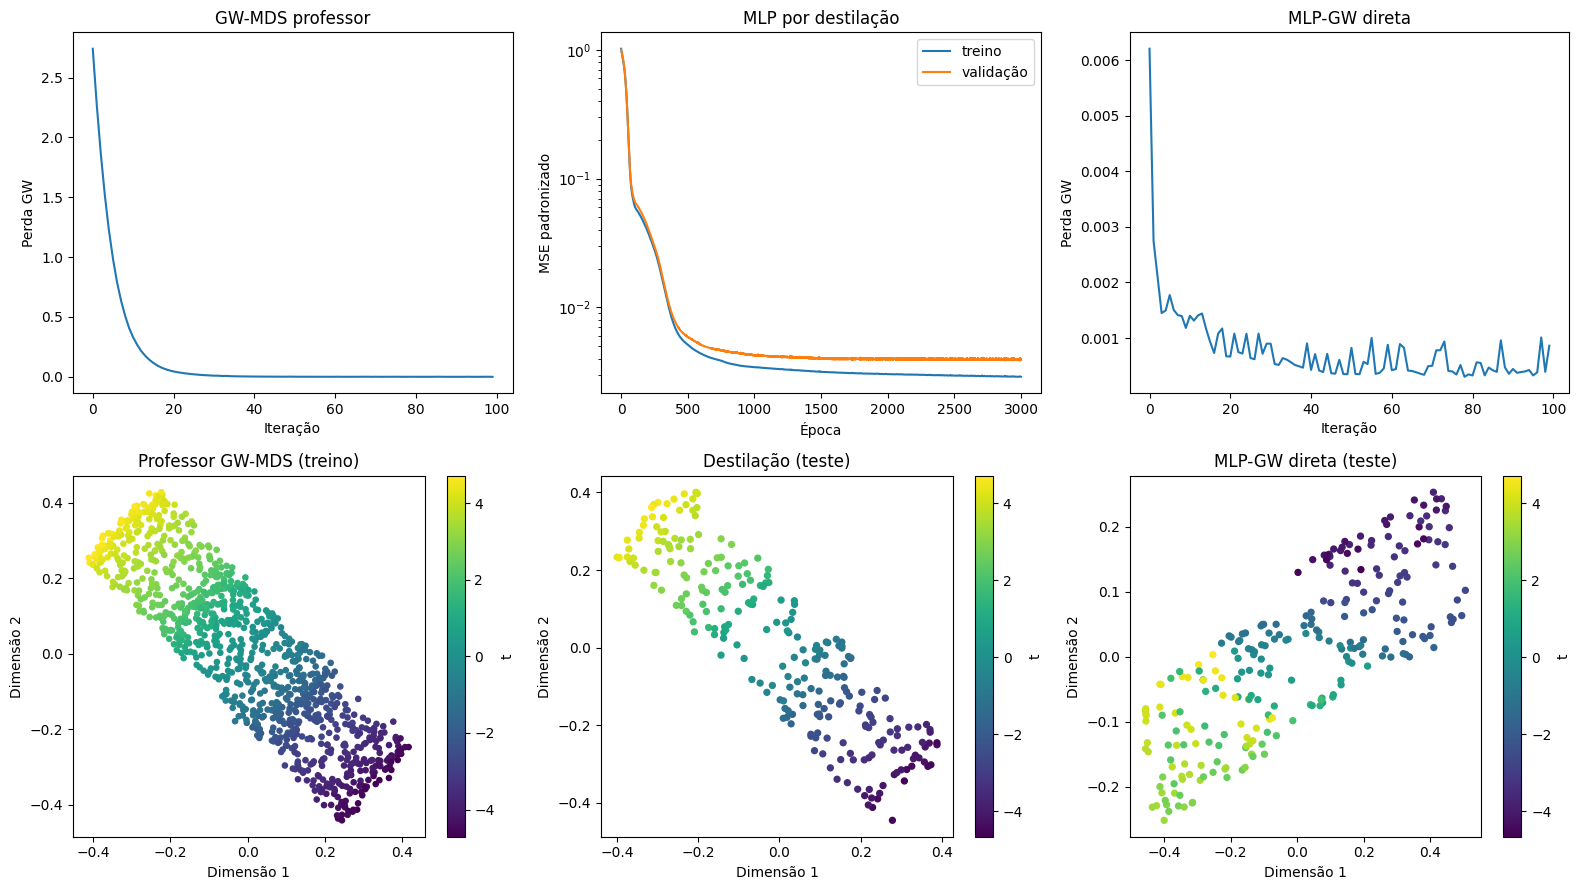

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

axes[0, 0].plot(teacher["history"])
axes[0, 0].set_title("GW-MDS professor")
axes[0, 0].set_xlabel("Iteração")
axes[0, 0].set_ylabel("Perda GW")

axes[0, 1].semilogy(mlp_history["train"], label="treino")
axes[0, 1].semilogy(mlp_history["val"], label="validação")
axes[0, 1].set_title("MLP por destilação")
axes[0, 1].set_xlabel("Época")
axes[0, 1].set_ylabel("MSE padronizado")
axes[0, 1].legend()

axes[0, 2].plot(direct_info["history"])
axes[0, 2].set_title("MLP-GW direta")
axes[0, 2].set_xlabel("Iteração")
axes[0, 2].set_ylabel("Perda GW")

sc0 = axes[1, 0].scatter(
    Y_teacher_train[:, 0],
    Y_teacher_train[:, 1],
    c=t_train,
    s=14,
    cmap="viridis",
)
axes[1, 0].set_title("Professor GW-MDS (treino)")
axes[1, 0].set_xlabel("Dimensão 1")
axes[1, 0].set_ylabel("Dimensão 2")
fig.colorbar(sc0, ax=axes[1, 0], label="t")

sc1 = axes[1, 1].scatter(
    Y_pred_test[:, 0],
    Y_pred_test[:, 1],
    c=t_test,
    s=18,
    cmap="viridis",
)
axes[1, 1].set_title("Destilação (teste)")
axes[1, 1].set_xlabel("Dimensão 1")
axes[1, 1].set_ylabel("Dimensão 2")
fig.colorbar(sc1, ax=axes[1, 1], label="t")

sc2 = axes[1, 2].scatter(
    Y_direct_test[:, 0],
    Y_direct_test[:, 1],
    c=t_test,
    s=18,
    cmap="viridis",
)
axes[1, 2].set_title("MLP-GW direta (teste)")
axes[1, 2].set_xlabel("Dimensão 1")
axes[1, 2].set_ylabel("Dimensão 2")
fig.colorbar(sc2, ax=axes[1, 2], label="t")

plt.tight_layout()
plt.show()

In [13]:
from pathlib import Path
import matplotlib.pyplot as plt

# Output directory
output_dir = Path("individual_figures")
output_dir.mkdir(parents=True, exist_ok=True)


def save_figure(fig, filename):
    fig.tight_layout()
    fig.savefig(
        output_dir / filename,
        format="pdf",
        bbox_inches="tight",
        dpi=300,
    )
    plt.close(fig)


# 1. GW-MDS teacher convergence
fig, ax = plt.subplots(figsize=(5.5, 4.0))
ax.plot(teacher["history"], linewidth=2)
ax.set_xlabel("Iteration")
ax.set_ylabel("GW loss")
# ax.set_title("GW-MDS teacher convergence")
ax.grid(alpha=0.25)
save_figure(fig, "gwmds_teacher_convergence.pdf")


# 2. Distillation training
fig, ax = plt.subplots(figsize=(5.5, 4.0))
ax.semilogy(mlp_history["train"], label="Training", linewidth=2)
ax.semilogy(mlp_history["val"], label="Validation", linewidth=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("Standardized MSE")
# ax.set_title("Student network training")
ax.legend()
ax.grid(alpha=0.25)
save_figure(fig, "student_distillation_training.pdf")


# 3. Direct GW training
fig, ax = plt.subplots(figsize=(5.5, 4.0))
ax.plot(direct_info["history"], linewidth=2)
ax.set_xlabel("Iteration")
ax.set_ylabel("GW loss")
# ax.set_title("Direct GW network training")
ax.grid(alpha=0.25)
save_figure(fig, "direct_gw_training.pdf")


# Common color scale for the embeddings
vmin = min(t_train.min(), t_test.min())
vmax = max(t_train.max(), t_test.max())


# 4. GW-MDS teacher embedding
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sc = ax.scatter(
    Y_teacher_train[:, 0],
    Y_teacher_train[:, 1],
    c=t_train,
    s=18,
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
)
ax.set_xlabel("Embedding dimension 1")
ax.set_ylabel("Embedding dimension 2")
# ax.set_title("GW-MDS teacher embedding (training set)")
# fig.colorbar(sc, ax=ax, label=r"S-curve parameter $t$")
save_figure(fig, "gwmds_teacher_train_embedding.pdf")


# 5. Distilled student embedding
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sc = ax.scatter(
    Y_pred_test[:, 0],
    Y_pred_test[:, 1],
    c=t_test,
    s=18,
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
)
ax.set_xlabel("Embedding dimension 1")
ax.set_ylabel("Embedding dimension 2")
# ax.set_title("Distilled student embedding (test set)")
# fig.colorbar(sc, ax=ax, label=r"S-curve parameter $t$")
save_figure(fig, "distilled_student_test_embedding.pdf")


# 6. Direct GW embedding
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sc = ax.scatter(
    Y_direct_test[:, 0],
    Y_direct_test[:, 1],
    c=t_test,
    s=18,
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
)
ax.set_xlabel("Embedding dimension 1")
ax.set_ylabel("Embedding dimension 2")
# ax.set_title("Direct GW network embedding (test set)")
# fig.colorbar(sc, ax=ax, label=r"S-curve parameter $t$")
save_figure(fig, "direct_gw_test_embedding.pdf")


print(f"Figures saved individually in: {output_dir.resolve()}")
for file in sorted(output_dir.glob("*.pdf")):
    print(f"  - {file.name}")

Figures saved individually in: /content/individual_figures
  - direct_gw_test_embedding.pdf
  - direct_gw_training.pdf
  - distilled_student_test_embedding.pdf
  - gwmds_teacher_convergence.pdf
  - gwmds_teacher_train_embedding.pdf
  - student_distillation_training.pdf


## 7. Como interpretar a comparação

O ponto principal é comparar, no **teste**, `MLP por destilação` e
`MLP-GW direta`:

- Pearson, Spearman e trustworthiness maiores indicam melhor preservação;
- stress menor é melhor;
- a variação contínua das cores permite verificar visualmente a S-curve;
- o tempo total mostra se eliminar a etapa de destilação compensa;
- a perda da MLP-GW direta deve estabilizar sem colapso geométrico.

A MLP-GW direta não utiliza a projeção baricêntrica nem a MSE: ela é treinada
somente pela estrutura relacional. Já a alternativa destilada recebe do
professor uma correspondência explícita entre cada entrada e seu alvo, o que
pode tornar a função indutiva mais fácil de aprender.

Este notebook produz uma primeira comparação controlada com uma única semente.
Para conclusões experimentais, o teste deve ser repetido com várias sementes e
os resultados devem ser apresentados como média e desvio-padrão.